In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

In [14]:
df  = pd.read_csv("../artifacts/raw/data.csv")

In [15]:
df.head()

,Timestamp,Machine_ID,Operation_Mode,Temperature_C,Vibration_Hz,Power_Consumption_kW,Network_Latency_ms,Packet_Loss_%,Quality_Control_Defect_Rate_%,Production_Speed_units_per_hr,Predictive_Maintenance_Score,Error_Rate_%,Efficiency_Status
0,2024-01-01 00:00:00,39,Idle,74.137590,3.500595,8.612162,10.650542,0.207764,7.751261,477.657391,0.344650,14.965470,Low
1,2024-01-01 00:01:00,29,Active,84.264558,3.355928,2.268559,29.111810,2.228464,4.989172,398.174747,0.769848,7.678270,Low
2,2024-01-01 00:02:00,15,Active,44.280102,2.079766,6.144105,18.357292,1.639416,0.456816,108.074959,0.987086,8.198391,Low
3,2024-01-01 00:03:00,43,Active,40.568502,0.298238,4.067825,29.153629,1.161021,4.582974,329.579410,0.983390,2.740847,Medium
4,2024-01-01 00:04:00,8,Idle,75.063817,0.345810,6.225737,34.029191,4.796520,2.287716,159.113525,0.573117,12.100686,Low


In [16]:
df["Efficiency_Status"].value_counts()

Efficiency_Status
Low       77825
Medium    19189
High       2986
Name: count, dtype: int64

In [17]:
df.columns

Index(['Timestamp', 'Machine_ID', 'Operation_Mode', 'Temperature_C',
       'Vibration_Hz', 'Power_Consumption_kW', 'Network_Latency_ms',
       'Packet_Loss_%', 'Quality_Control_Defect_Rate_%',
       'Production_Speed_units_per_hr', 'Predictive_Maintenance_Score',
       'Error_Rate_%', 'Efficiency_Status'],
      dtype='str')

In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 13 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Timestamp                      100000 non-null  str    
 1   Machine_ID                     100000 non-null  int64  
 2   Operation_Mode                 100000 non-null  str    
 3   Temperature_C                  100000 non-null  float64
 4   Vibration_Hz                   100000 non-null  float64
 5   Power_Consumption_kW           100000 non-null  float64
 6   Network_Latency_ms             100000 non-null  float64
 7   Packet_Loss_%                  100000 non-null  float64
 8   Quality_Control_Defect_Rate_%  100000 non-null  float64
 9   Production_Speed_units_per_hr  100000 non-null  float64
 10  Predictive_Maintenance_Score   100000 non-null  float64
 11  Error_Rate_%                   100000 non-null  float64
 12  Efficiency_Status              100000 non-

### DATA PROCESSING

In [19]:
df["Timestamp"] = pd.to_datetime(df["Timestamp"] , errors='coerce')

In [20]:
categorical_cols = ['Operation_Mode','Efficiency_Status']
for col in categorical_cols:
    df[col] = df[col].astype('category')

### EDA

In [21]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

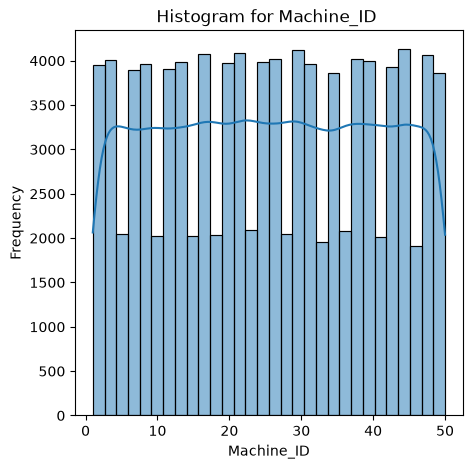

In [ ]:
for col in numeric_cols:
    plt.figure(figsize=(5,5))
    sns.histplot(df[col] , kde=True , bins=30)
    plt.title(f"Histogram for {col} ")
    plt.xlabel(col)
    plt.ylabel("Frequency")

    plt.show()

In [ ]:
sns.pairplot(df[numeric_cols])
plt.suptitle('Pair Plot for Numeric features' , y=1.02)
plt.show()

In [ ]:
plt.figure(figsize=(5,5))
sns.countplot(x='Efficiency_Status' , data=df , palette='viridis')
plt.title("Efficiemmcy status countplot")
plt.show()

### FE

In [ ]:
df.head()

In [ ]:
df["Year"] = df["Timestamp"].dt.year
df["Month"] = df["Timestamp"].dt.month
df["Day"] = df["Timestamp"].dt.day

df["Hour"] = df["Timestamp"].dt.hour

In [ ]:
df.drop(columns=["Timestamp","Machine_ID"] , inplace=True)

In [ ]:
df.shape

In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
label_encoder = LabelEncoder()
df["Efficiency_Target"] = label_encoder.fit_transform(df["Efficiency_Status"])

In [ ]:
label_encoder = LabelEncoder()
df["Operation_Mode"] = label_encoder.fit_transform(df["Operation_Mode"])

In [ ]:
df["Efficiency_Status"].value_counts()

In [ ]:
df["Efficiency_Target"].value_counts()

In [ ]:
df.columns

In [ ]:
features = [
    'Operation_Mode', 'Temperature_C', 'Vibration_Hz',
       'Power_Consumption_kW', 'Network_Latency_ms', 'Packet_Loss_%',
       'Quality_Control_Defect_Rate_%', 'Production_Speed_units_per_hr',
       'Predictive_Maintenance_Score', 'Error_Rate_%','Year', 'Month', 'Day', 'Hour'
]

In [ ]:
X = df[features]

In [ ]:
y = df["Efficiency_Target"]

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train , X_test , y_train , y_test = train_test_split(X_scaled,y, test_size=0.2 , random_state=42 , stratify=y)

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
clf = LogisticRegression(random_state=42,max_iter=1000)
clf.fit(X_train,y_train)

In [ ]:
y_pred = clf.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score , classification_report

In [ ]:
accuracy_score(y_test,y_pred)

In [ ]:
print(classification_report(y_test,y_pred))

In [ ]:
### Permutation imprtance

In [ ]:
from sklearn.inspection import permutation_importance

In [ ]:
result = permutation_importance(clf , X_test , y_test , n_repeats=10 , random_state=42 , n_jobs=-1)

In [ ]:
importance_df = pd.DataFrame({
    'Feature' : features,
    'Importances' : result.importances_mean
})

In [ ]:
importance_df.sort_values(by='Importances', ascending=False)